In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv(r"C:\Users\palak\Downloads\archive (8)\Employee.csv")
print(df.head())
print(df.info())

  EmployeeID   FirstName LastName      Gender  Age BusinessTravel  \
0  3012-1A41    Leonelle    Simco      Female   30    Some Travel   
1  CBCB-9C9D     Leonerd    Aland        Male   38    Some Travel   
2  95D7-1CE9       Ahmed    Sykes        Male   43    Some Travel   
3  47A0-559B  Ermentrude   Berrie  Non-Binary   39    Some Travel   
4  42CC-040A       Stace   Savege      Female   29    Some Travel   

        Department  DistanceFromHome (KM) State                Ethnicity  ...  \
0            Sales                     27    IL                    White  ...   
1            Sales                     23    CA                    White  ...   
2  Human Resources                     29    CA  Asian or Asian American  ...   
3       Technology                     12    IL                    White  ...   
4  Human Resources                     29    CA                    White  ...   

   MaritalStatus  Salary StockOptionLevel OverTime    HireDate  Attrition  \
0       Divorced  102

In [82]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [83]:
# Check missing values
print(df.isnull().sum())

EmployeeID                 0
FirstName                  0
LastName                   0
Gender                     0
Age                        0
BusinessTravel             0
Department                 0
DistanceFromHome (KM)      0
State                      0
Ethnicity                  0
Education                  0
EducationField             0
JobRole                    0
MaritalStatus              0
Salary                     0
StockOptionLevel           0
OverTime                   0
HireDate                   0
Attrition                  0
YearsAtCompany             0
YearsInMostRecentRole      0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64


In [84]:
# Fill numeric nulls with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [85]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [86]:
# Fill categorical nulls with mode
cat_cols = df.select_dtypes(include='object').columns

In [87]:
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [89]:
# Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60], labels=['18-25','26-35','36-45','46-60'])

In [90]:
# Income Category
df['IncomeLevel'] = pd.cut(df['Salary'],bins=3,labels=['Low', 'Medium', 'High'])

In [91]:
df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,IncomeLevel
0,3012-1A41,Leonelle,Simco,0.0,30,Some Travel,Sales,27,IL,White,...,1,No,2012-01-03,0,10,4,9,7,26-35,Low
1,CBCB-9C9D,Leonerd,Aland,1.0,38,Some Travel,Sales,23,CA,White,...,0,Yes,2012-01-04,0,10,6,10,0,36-45,Low
2,95D7-1CE9,Ahmed,Sykes,1.0,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,1,No,2012-01-04,0,10,6,10,8,36-45,Medium
3,47A0-559B,Ermentrude,Berrie,NaN,39,Some Travel,Technology,12,IL,White,...,0,No,2012-01-05,0,10,10,10,0,36-45,Medium
4,42CC-040A,Stace,Savege,0.0,29,Some Travel,Human Resources,29,CA,White,...,0,No,2012-01-05,1,6,1,1,6,26-35,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,1.0,20,Some Travel,Technology,28,CA,Black or African American,...,0,No,2022-12-26,0,0,0,0,0,18-25,Low
1466,6FB9-A624,Marc,Calver,NaN,27,Some Travel,Technology,8,CA,Black or African American,...,3,No,2022-12-30,0,0,0,0,0,26-35,Low
1467,EBF4-5928,Rudolph,MacDearmont,1.0,21,Some Travel,Sales,4,CA,Black or African American,...,0,No,2022-12-30,0,0,0,0,0,18-25,Low
1468,60E6-B1D9,Merill,Agg,1.0,21,Some Travel,Technology,7,CA,Black or African American,...,0,No,2022-12-30,0,0,0,0,0,18-25,Low


In [92]:
raw_df = pd.read_csv(r"C:\Users\palak\Downloads\archive (8)\Employee.csv")

df['Gender'] = raw_df['Gender']

In [93]:
print(df['Gender'].value_counts(dropna=False))

Gender
Female               675
Male                 651
Non-Binary           124
Prefer Not To Say     20
Name: count, dtype: int64


In [94]:
raw_df1 = pd.read_csv(r"C:\Users\palak\Downloads\archive (8)\Employee.csv")

df['Attrition'] = raw_df1['Attrition']

In [95]:
df

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,IncomeLevel
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,1,No,2012-01-03,No,10,4,9,7,26-35,Low
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,0,Yes,2012-01-04,No,10,6,10,0,36-45,Low
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,1,No,2012-01-04,No,10,6,10,8,36-45,Medium
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,0,No,2012-01-05,No,10,10,10,0,36-45,Medium
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,0,No,2012-01-05,Yes,6,1,1,6,26-35,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,467E-977A,Jud,Melanaphy,Male,20,Some Travel,Technology,28,CA,Black or African American,...,0,No,2022-12-26,No,0,0,0,0,18-25,Low
1466,6FB9-A624,Marc,Calver,Non-Binary,27,Some Travel,Technology,8,CA,Black or African American,...,3,No,2022-12-30,No,0,0,0,0,26-35,Low
1467,EBF4-5928,Rudolph,MacDearmont,Male,21,Some Travel,Sales,4,CA,Black or African American,...,0,No,2022-12-30,No,0,0,0,0,18-25,Low
1468,60E6-B1D9,Merill,Agg,Male,21,Some Travel,Technology,7,CA,Black or African American,...,0,No,2022-12-30,No,0,0,0,0,18-25,Low


In [98]:
# Save cleaned dataframe to CSV
df.to_csv(r"C:\Users\palak\Desktop\cleaned_hr_data.csv",index=False)

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

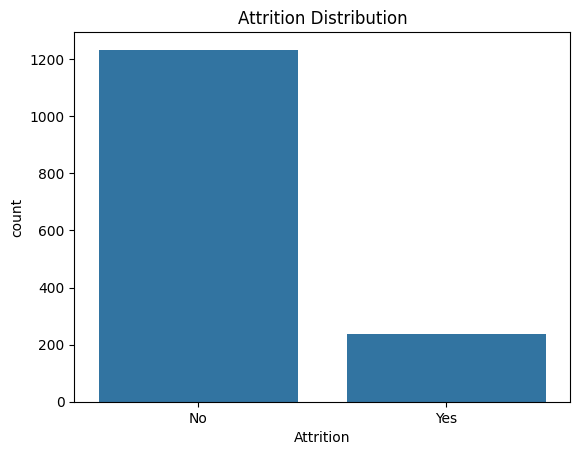

In [101]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()